# MODUL 3 - Perbaikan Citra dan Deteksi Tepi
------------------------------------------

In [572]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

## Import Library

Bagian ini mengimpor tiga library dengan kegunaan masing-masing yaitu:
- **NumPy (`np`)** — untuk operasi array dan matriks piksel secara efisien
- **Matplotlib (`plt`)** — untuk menampilkan citra dan histogram secara visual
- **OpenCV (`cv`)** — untuk membaca, mengkonversi, dan memproses citra

In [573]:
def convolution(img, kernel):
    # ukuran kernel / kernel size
    size = kernel.shape[0]
    # ukuran padding / padding size
    pad_size = size // 2
    # tambah padding nol / add zero padding
    padded = np.pad(img, pad_size, mode='constant')
    # kanvas hasil / output canvas
    canvas = np.zeros_like(img).astype(np.float32)
    # dimensi gambar / image dimensions
    height, width = img.shape
    # loop baris / loop rows
    for i in range(height):
        # loop kolom / loop columns
        for j in range(width):
            # area kernel / kernel region
            region = padded[i:i+size, j:j+size]
            # hitung konvolusi / compute convolution
            canvas[i, j] = np.sum(region * kernel)
    # kembalikan gambar / return image
    return canvas
# kernel penghalus gambar / image smoothing kernel
kernelSmoothing = np.array([
    [1/10, 1/10, 1/10],
    [1/10, 1/5,  1/10],
    [1/10, 1/10, 1/10]
])

kernelSharpening = np.array([
    [1/9, 1/9, 1/9],
    [1/9, 8/9, 1/9],
    [1/9, 1/9, 1/9]
])

(np.float64(-0.5), np.float64(799.5), np.float64(449.5), np.float64(-0.5))

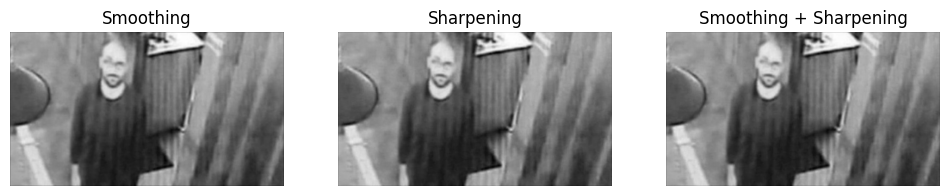

In [574]:
def tambah(citra1, citra2):
    hasil = citra1.astype(np.float32) + citra2.astype(np.float32)
    hasil = hasil * 255.0 / np.max(hasil)
    return np.clip(hasil, 0, 255).astype(np.uint8)

backup = cv.imread('backup.jpg')
backup = cv.cvtColor(backup,cv.COLOR_BGR2GRAY)

smoothing = convolution(backup,kernelSmoothing)
sharpening = convolution(backup,kernelSharpening)
smoothsharpening = tambah(smoothing,sharpening)

plt.figure(figsize=(12,6))
plt.subplot(1, 3, 1)
plt.imshow(smoothing, cmap='gray')
plt.title('Smoothing')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(sharpening, cmap='gray')
plt.title('Sharpening')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(smoothsharpening, cmap='gray')
plt.title('Smoothing + Sharpening')
plt.axis('off')


## Hasil Perbedaan Antara ke-3 Metode

- **Smoothing** — hasil dari citra yang sudah dilakukan smoothing, gambarnya jadi lebih halus akibat mengurangnya pixel yang terdapat pada gambar
- **Sharpening** — hasil dari citra yang sudah dilakukan sharpening, gambarnya jadi lebih tajam akibat menambahnya pixel yang terdapat pada gambar
- **Smoothing +  Sharpening** — untuk hasil citra pada metode ini pixel dalam gambar jadi lebih seimbang

In [575]:
def filter(img, size, mode):
    # dimensi gambar / image dimensions
    height, width = img.shape
    # ukuran padding / padding size
    pad = size // 2
    # tambah padding tepi / add edge padding
    padded = np.pad(img, pad, mode='edge')
    # kanvas hasil / output canvas
    canvas = np.zeros_like(img, dtype=np.uint8)

    match mode:
        case 'mean':
            # filter rata-rata / mean filter
            area = size * size
            for i in range(height):
                for j in range(width):
                    # area kernel / kernel region
                    region = padded[i:i+size, j:j+size]
                    # rumus mean manual / manual mean formula
                    canvas[i, j] = np.sum(region) // area

        case 'median':
            # filter median / median filter
            for i in range(height):
                for j in range(width):
                    # area kernel / kernel region
                    region = padded[i:i+size, j:j+size]
                    # rumus median manual / manual median formula
                    values = np.sort(region.ravel())
                    mid = len(values) // 2
                    canvas[i, j] = values[mid]

        case 'modus':
            # filter modus / mode filter
            for i in range(height):
                for j in range(width):
                    # area kernel / kernel region
                    region = padded[i:i+size, j:j+size]
                    # ratakan array / flatten array
                    values = region.ravel()
                    # hitung kemunculan / count occurrences
                    count = {}
                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1
                    # cari nilai terbanyak / find mode value
                    max_count = 0
                    mode_val = 0
                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val
                    # simpan hasil / save result
                    canvas[i, j] = mode_val

    # kembalikan gambar / return image
    return canvas

(np.float64(-0.5), np.float64(799.5), np.float64(449.5), np.float64(-0.5))

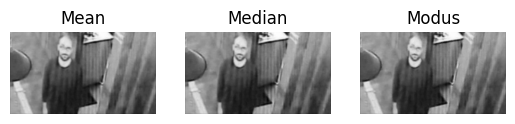

In [576]:
mean = filter(smoothsharpening,3,'mean')
median = filter(smoothsharpening,3,'median')
modus = filter(smoothsharpening,3,'modus')

plt.subplot(1,3,1)
plt.imshow(mean, cmap='gray')
plt.title('Mean')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(median, cmap='gray')
plt.title('Median')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(modus, cmap='gray')
plt.title('Modus')
plt.axis('off')

## Hasil Perbedaan Antara Mean,Median dan Modus

- **Mean** — hasil dari citra yang sudah dilakukan mean, pixel dalam citra dirombak ulang dan akan menggunakan matriks piksel yang sudah dirata-takan.
- **Median** — hasil dari citra yang sudah dilakukan median, pixel dalam citra dirombak ulang dan akan menggunakan matriks piksel yang sudah menggunakan array yang tengah.
- **Modus** — hasil dari citra yang sudah dilakukan modus, pixel dalam citra dirombak ulang dan akan menggunakan matriks piksel yang paling banyak muncul.

In [577]:
# kernel roberts sumbu x / x-axis roberts kernel
robertsX = np.array([
    [1, 0],
    [0, -1],
], dtype=np.float32)

# kernel roberts sumbu y / y-axis roberts kernel
robertsY = np.array([
    [0, 1],
    [-1, 0]
], dtype=np.float32)

# kernel prewitt sumbu x / x-axis prewitt kernel
prewittX = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
], dtype=np.float32)

# kernel prewitt sumbu y / y-axis prewitt kernel
prewittY = np.array([
    [1, 1, 1],
    [0, 0, 0],
    [-1, -1, -1]
], dtype=np.float32)

# kernel sobel sumbu x / x-axis sobel kernel
sobelX = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float32)

# kernel sobel sumbu y / y-axis sobel kernel
sobelY = np.array([
    [1, 2, 1],
    [0, 0, 0],
    [-1, -2, -1]
], dtype=np.float32)

In [578]:
def edge(img, kernelx, kernely):
    # konvolusi sumbu x / x-axis convolution
    gx = convolution(img, kernelx)
    # konvolusi sumbu y / y-axis convolution
    gy = convolution(img, kernely)
    # kanvas kosong / empty canvas
    canvas = np.zeros_like(img, dtype=np.float32)
    # gabung gradien absolut / combine absolute gradients
    canvas = np.sqrt(gx**2 + gy**2)
    # normalisasi ke 0-255 / normalize to 0-255
    canvas = canvas * 255.0 / np.max(canvas)
    # batas nilai dan konversi / clip values and convert
    return np.clip(canvas, 0, 255).astype(np.uint8)

In [579]:
def normalisasi(citra):
    min_val = int(citra[0,0])
    max_val = int(citra[0,0])
    for i in range(citra.shape[0]):
        for j in range(citra.shape[1]):
            if citra[i,j] < min_val: min_val = int(citra[i,j])
            if citra[i,j] > max_val: max_val = int(citra[i,j])
    
    hasil = np.zeros(citra.shape, dtype=np.uint8)
    for i in range(citra.shape[0]):
        for j in range(citra.shape[1]):
            hasil[i,j] = int((int(citra[i,j]) - min_val) / (max_val - min_val) * 255)
    return hasil

In [ ]:

prewitt   = edge(backup,    prewittX, prewittY)
prewitt = normalisasi(prewitt) 
sobel   = edge(backup,    sobelX, sobelY)
sobel = normalisasi(sobel)
roberts   = edge(backup,    robertsX, robertsY)
roberts = normalisasi (roberts)
prewitt_sobel = edge (backup, prewittX, prewittY) + edge(backup, sobelX, sobelY)
prewitt_sobel = normalisasi(prewitt_sobel)

prewitt_roberts = edge (backup, prewittX, prewittY) + edge(backup, robertsX, robertsY)
prewitt_roberts = normalisasi (prewitt_roberts)
sobel_roberts = edge (backup, sobelX, sobelY) + edge(backup, robertsX, robertsY)
sobel_roberts = normalisasi (sobel_roberts)
prewitt_sobel_roberts = edge (backup, prewittX, prewittY) + edge(backup, sobelX, sobelY) + edge(smoothsharpening, robertsX, robertsY)
prewitt_sobel_roberts = normalisasi (prewitt_sobel_roberts)



plt.figure(figsize=(16,8))
plt.subplot(4,4,1)
plt.imshow(prewitt, cmap='gray')
plt.title('Prewitt')
plt.axis('off')

plt.subplot(4,4,2)
plt.imshow(sobel, cmap='gray')
plt.title('Sobel')
plt.axis('off')

plt.subplot(4,4,3)
plt.imshow(roberts, cmap='gray')
plt.title('Roberts')
plt.axis('off')

plt.subplot(4,4,4)
plt.imshow(prewitt_sobel, cmap='gray')
plt.title('Prewitt + Sobel')
plt.axis('off')

plt.subplot(4,4,5)
plt.imshow(prewitt_roberts, cmap='gray')
plt.title('Prewitt + Roberts')
plt.axis('off')

plt.subplot(4,4,6)
plt.imshow(sobel_roberts, cmap='gray')
plt.title('Sobel + Roberts')
plt.axis('off')

plt.subplot(4,4,7)
plt.imshow(prewitt_sobel_roberts, cmap='gray')
plt.title('Prewitt + Sobel + Roberts')
plt.axis('off')


## Kegunaan Operator dan Kombinasi Operator

## Kegunaan Operator dan Kombinasi Operator

**Prewitt** adalah operator deteksi tepi berbasis gradien menggunakan kernel 3×3 yang menghitung perubahan intensitas secara horizontal dan vertikal dengan bobot seragam. Hasilnya cukup baik dalam mendeteksi tepi lurus namun kurang sensitif terhadap tepi diagonal.

**Sobel** mirip dengan Prewitt namun memberikan bobot lebih besar pada piksel yang tepat di samping piksel pusat (bobot 2 pada baris/kolom tengah). Hal ini membuat Sobel lebih sensitif terhadap tepi dan menghasilkan garis tepi yang lebih tebal dan lebih kuat dibanding Prewitt, sehingga lebih cocok untuk citra dengan noise.

**Roberts** menggunakan kernel 2×2 yang menghitung gradien diagonal. Hasilnya menghasilkan garis tepi yang sangat tipis dan tajam, namun lebih sensitif terhadap noise karena kernel yang kecil tidak melakukan smoothing apapun sebelum deteksi.

**Prewitt + Sobel** menggabungkan kekuatan kedua operator 3×3. Tepi yang terdeteksi menjadi lebih lengkap dan lebih tebal karena dua respons gradien dijumlahkan, sehingga tepi lemah yang mungkin terlewat salah satu operator dapat ikut tertangkap.

**Prewitt + Roberts** menggabungkan tepi horizontal/vertikal dari Prewitt dengan tepi diagonal dari Roberts. Hasilnya mencakup lebih banyak arah tepi namun noise dari Roberts ikut terbawa, membuat hasil kurang bersih dibanding Prewitt + Sobel.

**Sobel + Roberts** menghasilkan efek serupa dengan Prewitt + Roberts namun tepi dari Sobel lebih kuat, sehingga dominasi tepi horizontal/vertikal lebih terasa dengan sedikit tambahan tepi diagonal dari Roberts.

**Prewitt + Sobel + Roberts** merupakan gabungan ketiga operator sekaligus. Hasilnya paling lengkap dalam menangkap semua arah tepi, namun juga paling rentan terhadap noise karena semua respons dijumlahkan termasuk noise dari Roberts.

(np.float64(-0.5), np.float64(799.5), np.float64(449.5), np.float64(-0.5))

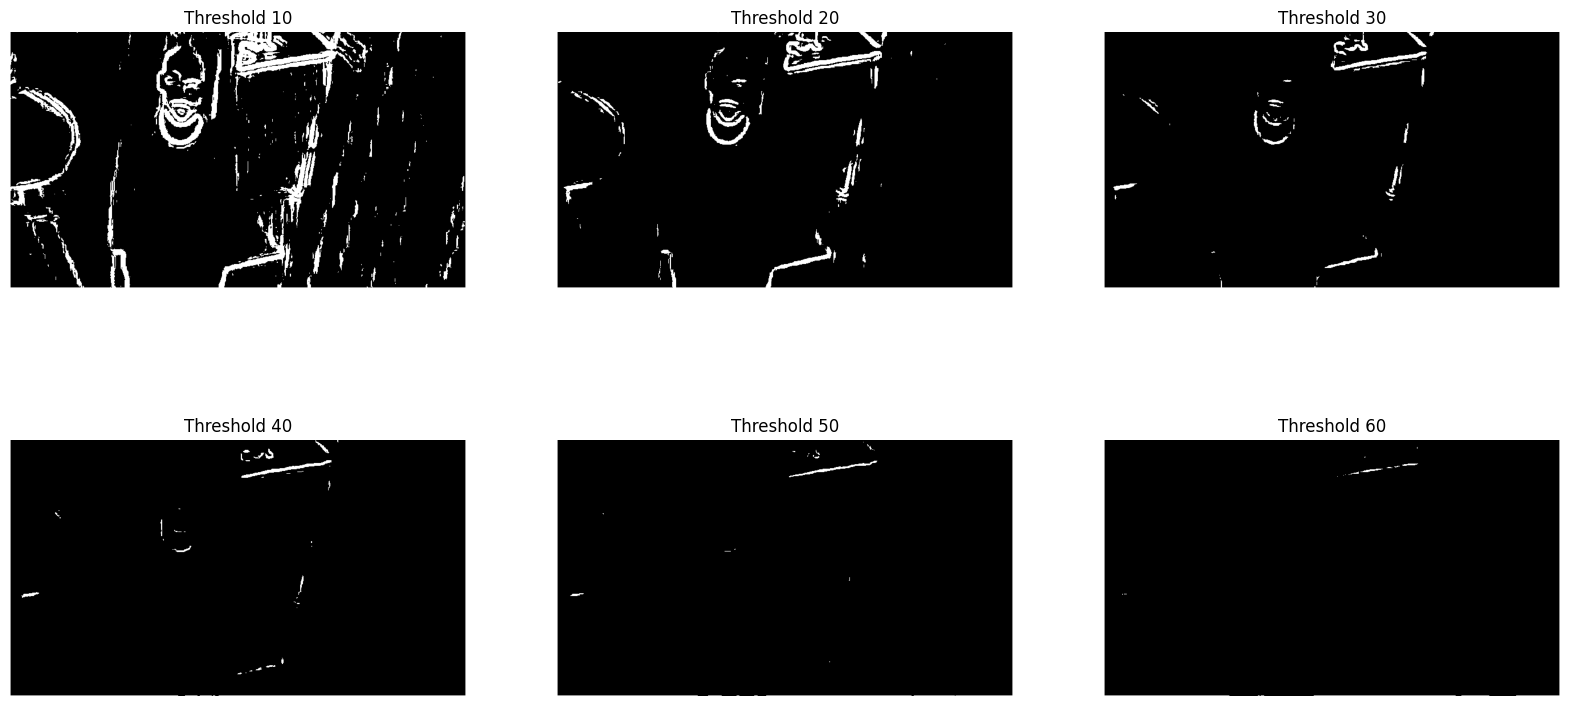

In [ ]:
def threshold (img,th):
    return(img > th).astype(np.uint8)*255

th_10 = threshold(sobel,10)
th_20 = threshold(sobel,20)
th_30 = threshold(sobel,30)
th_40 = threshold(sobel,40)
th_50 = threshold(sobel,50)
th_60 = threshold(sobel,60)

plt.figure(figsize=(20,15))
plt.subplot(3,3,1)
plt.imshow(th_10, cmap='gray')
plt.title('Threshold 10')
plt.axis('off')

plt.subplot(3,3,2)
plt.imshow(th_20, cmap='gray')
plt.title('Threshold 20')
plt.axis('off')

plt.subplot(3,3,3)
plt.imshow(th_30, cmap='gray')
plt.title('Threshold 30')
plt.axis('off')

plt.subplot(3,3,4)
plt.imshow(th_40, cmap='gray')
plt.title('Threshold 40')
plt.axis('off')

plt.subplot(3,3,5)
plt.imshow(th_50, cmap='gray')
plt.title('Threshold 50')
plt.axis('off')

plt.subplot(3,3,6)
plt.imshow(th_60, cmap='gray')
plt.title('Threshold 60')
plt.axis('off')


## Pengaruh Threshold pada Deteksi Tepi

Threshold berfungsi sebagai filter biner yang memutuskan piksel mana yang dianggap sebagai tepi (putih) dan mana yang bukan (hitam), berdasarkan kekuatan gradiennya.

**Threshold rendah (nilai 10–20)** menghasilkan banyak piksel putih karena hampir semua gradien dianggap sebagai tepi. Akibatnya citra penuh dengan detail tepi termasuk noise dan tekstur halus yang tidak relevan, sehingga sulit membedakan tepi objek utama dari latar.

**Threshold tinggi (nilai 50–60)** hanya mempertahankan tepi dengan gradien sangat kuat. Hasilnya lebih bersih dan minim noise, namun banyak tepi penting yang hilang sehingga bentuk objek menjadi tidak lengkap dan terputus-putus.

**Threshold terbaik untuk kasus CCTV ini adalah nilai 20–30.** Pada nilai tersebut, kontur orang (kepala, bahu, badan) masih terdeteksi dengan cukup jelas tanpa terlalu banyak noise dari tekstur latar belakang kayu. Nilai ini memberikan keseimbangan antara kelengkapan informasi tepi dan kebersihan hasil deteksi.

(np.float64(-0.5), np.float64(799.5), np.float64(449.5), np.float64(-0.5))

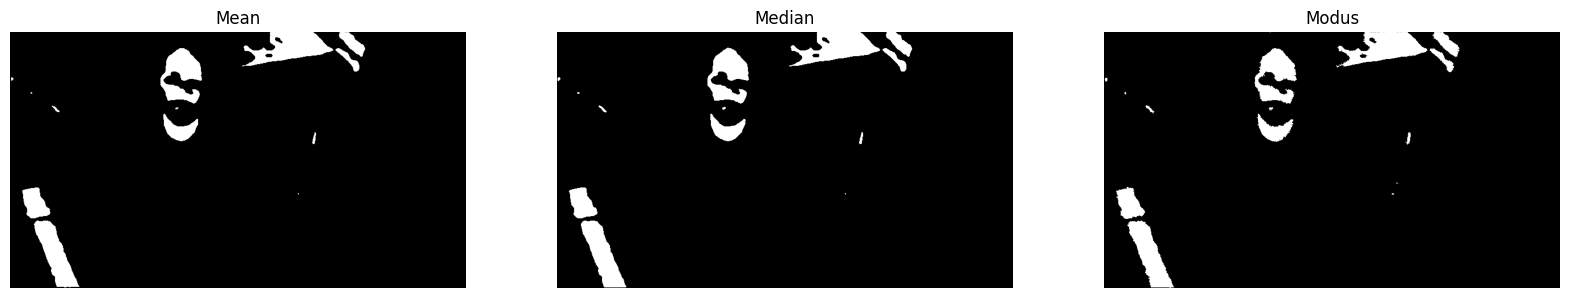

In [ ]:
gambar1 = threshold(mean,200)
gambar2 = threshold(median,200)
gambar3 = threshold(modus,200)

plt.figure(figsize=(20,15))
plt.subplot(1,3,1)
plt.imshow(gambar1, cmap='gray')
plt.title('Mean')
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(gambar2, cmap='gray')
plt.title('Median')
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(gambar3, cmap='gray')
plt.title('Modus')
plt.axis('off')



In [ ]:
def copy(gambar):
    h, w = gambar.shape
    hasil = np.zeros((h, w), dtype=gambar.dtype)

    for i in range(h):
        for j in range(w):
            hasil[i][j] = gambar[i][j]

    return hasil

def gabungin(citra_depan, citra_belakang):
    hasil = copy(citra_depan)

    for i in range(citra_depan.shape[0]):
        for j in range(citra_depan.shape[1]):
            if citra_depan[i, j] > 50:   # area putih → tampilkan ledakan
                hasil[i, j] = citra_belakang[i, j]
            else:                         # area hitam → tetap hitam
                hasil[i, j] = 0

    return hasil

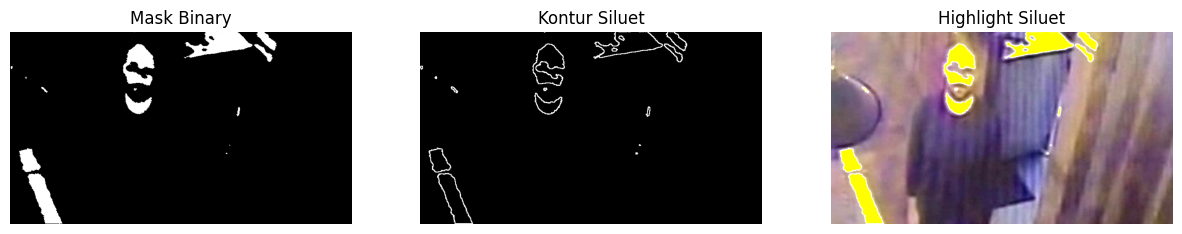

In [ ]:
# Highlight siluet orang ke citra warna asli (kuning)
backup_color = cv.imread('backup.jpg')
backup_color = cv.cvtColor(backup_color, cv.COLOR_BGR2RGB)

mask = gambar3  # binary mask dari threshold

# Buat highlight kuning di area mask
highlighted = backup_color.copy()
highlighted[mask > 0] = [255, 255, 0]  # warna kuning

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(mask, cmap='gray')
plt.title('Mask Binary')
plt.axis('off')

plt.subplot(1, 3, 2)
# contour dari mask
contour_img = np.zeros_like(mask)
# pakai edge detection sederhana pada mask
contour_img = edge(mask, sobelX, sobelY)
th_contour = threshold(contour_img, 10)
plt.imshow(th_contour, cmap='gray')
plt.title('Kontur Siluet')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(highlighted)
plt.title('Highlight Siluet')
plt.axis('off')
plt.show()

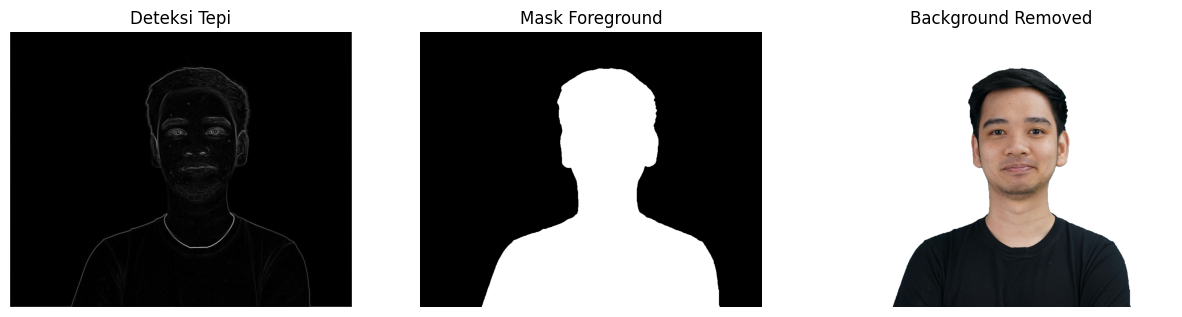

In [ ]:
david = cv.imread('david.jpg')
david_rgb = cv.cvtColor(david, cv.COLOR_BGR2RGB)

# 1. Deteksi Tepi
david_gray = cv.cvtColor(david, cv.COLOR_BGR2GRAY)
david_edge = edge(david_gray, sobelX, sobelY)

# 2. Background Removal — deteksi background toska (B & G tinggi, R rendah)
R = david_rgb[:, :, 0].astype(np.float32)
G = david_rgb[:, :, 1].astype(np.float32)
B = david_rgb[:, :, 2].astype(np.float32)

# Toska: G dan B dominan, R rendah, dan G ≈ B
is_background = (B > R + 30) & (G > R + 20) & (np.abs(G.astype(int) - B.astype(int)) < 60)

# Foreground mask
foreground_mask = (~is_background).astype(np.uint8) * 255

# Terapkan median filter untuk rapikan mask
foreground_mask = filter(foreground_mask, 5, 'median')

# 3. Hasil: background jadi putih
result = david_rgb.copy()
result[foreground_mask == 0] = [255, 255, 255]

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(david_edge, cmap='gray')
plt.title('Deteksi Tepi')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(foreground_mask, cmap='gray')
plt.title('Mask Foreground')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(result)
plt.title('Background Removed')
plt.axis('off')
plt.show()

## Proses Perbaikan dan Deteksi Tepi — david.jpg

**Deteksi Tepi:** Citra `david.jpg` dikonversi ke grayscale terlebih dahulu, kemudian diterapkan operator Sobel untuk mendeteksi tepi. Karena pencahayaan pada pas foto lebih merata dan kontras lebih baik dibanding citra CCTV, tepi wajah, rambut, dan pakaian dapat terdeteksi dengan lebih jelas dan bersih.

**Background Removal:** Proses penghilangan background dilakukan dengan memisahkan kanal RGB dari citra asli. Background berwarna toska diidentifikasi berdasarkan kondisi: kanal Biru (B) dan Hijau (G) dominan melebihi kanal Merah (R), serta selisih antara G dan B tidak terlalu jauh (warna toska = campuran hijau dan biru). Piksel yang memenuhi kondisi tersebut diklasifikasikan sebagai background.

Area foreground (subjek/orang) adalah piksel yang tidak memenuhi kondisi background. Median filter kemudian diterapkan pada mask foreground untuk merapikan piksel-piksel kecil yang salah terklasifikasi (noise), tanpa menggunakan operasi morfologi sebagai proses utama. Hasilnya, area background diganti menjadi putih sementara subjek dipertahankan sesuai warna aslinya.



## Kesimpulan

Perbaikan kualitas citra (smoothing, sharpening) dan deteksi tepi merupakan dua tahap fundamental dalam pengolahan citra digital. Smoothing membantu mengurangi noise sehingga proses selanjutnya tidak terganggu oleh artefak, sementara sharpening mengembalikan ketajaman detail yang dibutuhkan. Deteksi tepi dengan operator Prewitt, Sobel, dan Roberts memungkinkan ekstraksi informasi bentuk dan kontur objek dari citra. Pemilihan operator dan nilai threshold yang tepat sangat berpengaruh terhadap kualitas hasil — threshold terlalu rendah menghasilkan terlalu banyak noise, sementara terlalu tinggi menghilangkan informasi penting. Kombinasi beberapa operator dapat meningkatkan kelengkapan deteksi tepi dari berbagai arah. Pada kasus nyata seperti citra CCTV berkualitas rendah maupun pas foto berkualitas baik, pipeline ini terbukti mampu mengekstrak informasi bentuk dan memisahkan subjek dari latar belakang.